# Use case 2: zoo mammal feces by diet (MSV000086131)

**Produces:** Figure 2B (`figure2_2b_independent_y_axes`) and its source table of pairwise tests (`source_figure2_2b_pairwise_diet_tests.csv`).

**Inputs:** GNPS2 FBMN task `3d18cb7996ce4e478a52ec2ab1c80f9d` (quantification table downloaded and cached in `data/`), the post-molecular-networking MassQL table `postMN_massql_animal_zoo_library_matches.tsv` and the diet metadata `animal_zoo_metadata_FBMN.txt` (set `BASE_DIR` in the config cell).

In [1]:
import os

# Root of the local project folder (the one holding Falcon/, Queries_final_mgf/,
# final_mgfs_library_generation/, ...). Edit this single line to run elsewhere.
PROJECT_DIR = '/media/dorrestein/Helena2/Bile_acids_update'

# Fecal bile-acid core composition by animal diet

Samples are fecal samples grouped as herbivore, omnivore, or carnivore. Abundances are closed within each sample: every value is the percentage of that sample's validated, annotated bile-acid signal assigned to a core.

In [2]:
%matplotlib inline
# ============================== CONFIG =======================================
import re
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

TASK_ID = '3d18cb7996ce4e478a52ec2ab1c80f9d'
BASE_DIR = Path(f'{PROJECT_DIR}/Examples/animal_zoo')
METADATA_PATH = BASE_DIR / 'animal_zoo_metadata_FBMN.txt'
MASSQL_PATH = BASE_DIR / 'postMN_massql_animal_zoo_library_matches.tsv'
MASSQL_SKIPROWS = 26
DATA_DIR = Path('data')
FIG_DIR = Path('figures') / 'animal_zoo_diet'
SAVE_FIGURES = True
EXCLUDE_POTENTIAL_ISF = False  # set True to drop 'potential ISF' library hits
DPI = 300

DIET_ORDER = ['herbivore', 'omnivore', 'carnivore']
CORE_ORDER = ['C23', 'C24', 'C24_alkamine', 'C26', 'C27', 'C28_alcohol']
CORE_LABEL = {'C23':'C23', 'C24':'C24', 'C24_alkamine':'C24 alkamine',
              'C26':'C26', 'C27':'C27', 'C28_alcohol':'C28 alcohol'}
CORE_COLORS = {'C23':'#2a78d6', 'C24':'#eb6834', 'C24_alkamine':'#1baf7a',
               'C26':'#eda100', 'C27':'#e87ba4', 'C28_alcohol':'#008300'}
DIET_COLORS = {'herbivore':'#4b9b57', 'omnivore':'#7a6fc2', 'carnivore':'#c45b52'}

mpl.rcParams.update({'pdf.fonttype':42, 'ps.fonttype':42, 'savefig.dpi':DPI})
DATA_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
for p in (METADATA_PATH, MASSQL_PATH):
    if not p.exists():
        raise FileNotFoundError(f'Missing local input: {p}')
print(f'task={TASK_ID} | exclude potential ISF={EXCLUDE_POTENTIAL_ISF}')

task=3d18cb7996ce4e478a52ec2ab1c80f9d | exclude potential ISF=False


## 1. Load, validate, and normalize

The GNPS2 quantification table is downloaded once and cached. The local post-networking MassQL table already contains both the library annotations and the query-validation result, so a second library-match download/merge is unnecessary.

In [3]:
def fetch(url, path, what):
    if path.exists():
        print(f'{what}: cached at {path}')
        return path
    print(f'{what}: downloading from GNPS2 ...')
    response = requests.get(url, timeout=900)
    response.raise_for_status()
    path.write_bytes(response.content)
    print(f'{what}: saved {path} ({path.stat().st_size / 1e6:.1f} MB)')
    return path

quant_path = fetch(
    f'https://gnps2.org/result?task={TASK_ID}&viewname=quantificationdownload&resultdisplay_type=task',
    DATA_DIR / f'{TASK_ID}_quant.csv', 'quantification table')

quant = pd.read_csv(quant_path, low_memory=False)
area_cols = [c for c in quant.columns if c.endswith('Peak area')]
if not area_cols:
    raise ValueError('No columns ending in `Peak area` were found in the GNPS table')
X_all = quant.set_index('row ID')[area_cols].astype('float64').T
X_all.index = pd.Index(
    [re.sub(r'\.(mzML|mzXML) Peak area$', '', c, flags=re.I) for c in area_cols],
    name='filename')
del quant

metadata = pd.read_csv(METADATA_PATH, sep='\t')
metadata['filename'] = metadata['filename'].str.replace(r'\.(mzML|mzXML)$', '', regex=True)
metadata['diet'] = metadata['ATTRIBUTE_diet'].str.strip().str.lower()
unexpected = sorted(set(metadata['diet'].dropna()) - set(DIET_ORDER))
if unexpected:
    raise ValueError(f'Unexpected diet labels: {unexpected}')
metadata = metadata.drop_duplicates('filename').set_index('filename')
matched_files = X_all.index.intersection(metadata.index, sort=False)
samples = metadata.loc[matched_files].copy()
print(f'{X_all.shape[0]} quantified files; {len(samples)} matched diet metadata rows')
print(samples['diet'].value_counts().reindex(DIET_ORDER).fillna(0).astype(int))

quantification table: downloading from GNPS2 ...
quantification table: saved data/3d18cb7996ce4e478a52ec2ab1c80f9d_quant.csv (17.6 MB)
144 quantified files; 101 matched diet metadata rows
diet
herbivore    50
omnivore     38
carnivore    13
Name: count, dtype: int64


In [4]:
massql_all = pd.read_csv(MASSQL_PATH, sep='\t', skiprows=MASSQL_SKIPROWS, low_memory=False)
validated = massql_all.loc[
    massql_all['query_validation'].notna()
    & massql_all['query_validation'].ne('Did not pass any selected query')
].copy()
if EXCLUDE_POTENTIAL_ISF:
    validated = validated.loc[
        ~validated['Compound_Name'].astype('string').str.contains('potential ISF', case=False, na=False)
    ].copy()

def classify_ba_core(library_name):
    name = '' if pd.isna(library_name) else str(library_name)
    if name.startswith('C24_alkamine'): return 'C24_alkamine'
    if name.startswith('C23'): return 'C23'
    if name.startswith('C24'): return 'C24'
    if name.startswith('C26'): return 'C26'
    if name.startswith('C27'): return 'C27'
    if name.startswith('C28'): return 'C28_alcohol'
    return pd.NA

validated['BA_core'] = validated['LibraryName'].map(classify_ba_core)
if validated['BA_core'].isna().any():
    bad = validated.loc[validated['BA_core'].isna(), 'LibraryName'].unique()
    raise ValueError(f'Unclassified validated libraries: {bad}')
if validated['#Scan#'].duplicated().any():
    raise ValueError('Validated table has duplicate scan IDs; resolve before summing')

core_of_feature = validated.set_index('#Scan#')['BA_core'].astype(str).sort_index()
missing_features = core_of_feature.index.difference(X_all.columns)
if len(missing_features):
    raise ValueError(f'{len(missing_features)} validated scans are absent from quantification')
A_ba = X_all.loc[samples.index, core_of_feature.index]
total_ba_area = A_ba.sum(axis=1)
zero_files = total_ba_area.index[total_ba_area <= 0]
if len(zero_files):
    print(f'Dropping {len(zero_files)} metadata-matched files with zero selected BA signal')
samples = samples.drop(index=zero_files)
A_ba = A_ba.drop(index=zero_files)
total_ba_area = total_ba_area.drop(index=zero_files)

core_area = A_ba.T.groupby(core_of_feature).sum().T.reindex(columns=CORE_ORDER, fill_value=0.0)
core_pct = 100 * core_area.div(total_ba_area, axis=0)
assert np.allclose(core_pct.sum(axis=1), 100), 'Core percentages do not close to 100%'
feature_counts = core_of_feature.value_counts().reindex(CORE_ORDER, fill_value=0).astype(int)
print(f'{len(validated)} validated features retained across {len(samples)} samples')
display(pd.DataFrame({'features': feature_counts, 'samples_detected': (core_area > 0).sum()}))

610 validated features retained across 101 samples


,features,samples_detected
BA_core,,
C23,10,101
C24,360,101
C24_alkamine,172,101
C26,0,0
C27,30,100
C28_alcohol,38,101


## 2. Pairwise statistics

Diets are compared two at a time *within each core* using two-sided Mann–Whitney U tests, because the diet groups contain different samples. Benjamini–Hochberg correction is applied across the complete family of tests (15 tests when five cores are observed). C26 is displayed but not tested because it has no validated features.

In [5]:
from itertools import combinations
from scipy.stats import mannwhitneyu

observed_cores = [core for core in CORE_ORDER if feature_counts[core] > 0]

def benjamini_hochberg(p_values):
    """Return BH-adjusted p values in the original row order."""
    p = np.asarray(p_values, dtype=float)
    order = np.argsort(p)
    ranked = p[order]
    adjusted_ranked = np.minimum.accumulate(
        (ranked * len(p) / np.arange(1, len(p) + 1))[::-1])[::-1]
    adjusted = np.empty_like(adjusted_ranked)
    adjusted[order] = np.clip(adjusted_ranked, 0, 1)
    return adjusted

def significance_label(q):
    if q < .001: return '***'
    if q < .01: return '**'
    if q < .05: return '*'
    return 'ns'

def format_q(q):
    if q < .001: return f'{q:.1e}'
    if q < .01: return f'{q:.3f}'
    return f'{q:.2f}'

# Figure 2.2b family: all three diet pairs for every observed core.
rows = []
for core in observed_cores:
    for diet1, diet2 in combinations(DIET_ORDER, 2):
        x = core_pct.loc[samples.index[samples['diet'].eq(diet1)], core].to_numpy()
        y = core_pct.loc[samples.index[samples['diet'].eq(diet2)], core].to_numpy()
        statistic, p_value = mannwhitneyu(x, y, alternative='two-sided', method='auto')
        rows.append({'core': core, 'diet_1': diet1, 'diet_2': diet2,
                     'test': 'Mann-Whitney U', 'statistic': statistic,
                     'p_value': p_value})
pairwise_diets = pd.DataFrame(rows)
pairwise_diets['q_value_BH'] = benjamini_hochberg(pairwise_diets['p_value'])
pairwise_diets['significance'] = pairwise_diets['q_value_BH'].map(significance_label)

print(f'Figure 2.2b: {len(pairwise_diets)} tests')
display(pairwise_diets.round({'statistic': 2, 'p_value': 5, 'q_value_BH': 5}))

Figure 2.2b: 15 tests


,core,diet_1,diet_2,test,statistic,p_value,q_value_BH,significance
0,C23,herbivore,omnivore,Mann-Whitney U,1694.0,0.00000,0.00000,***
1,C23,herbivore,carnivore,Mann-Whitney U,649.0,0.00000,0.00000,***
2,C23,omnivore,carnivore,Mann-Whitney U,444.0,0.00002,0.00005,***
3,C24,herbivore,omnivore,Mann-Whitney U,1194.0,0.04024,0.05030,ns
4,C24,herbivore,carnivore,Mann-Whitney U,476.0,0.01058,0.01512,*
5,C24,omnivore,carnivore,Mann-Whitney U,261.0,0.77045,0.77045,ns
6,C24_alkamine,herbivore,omnivore,Mann-Whitney U,648.0,0.01109,0.01512,*
7,C24_alkamine,herbivore,carnivore,Mann-Whitney U,154.0,0.00378,0.00630,**
8,C24_alkamine,omnivore,carnivore,Mann-Whitney U,213.0,0.46903,0.50254,ns
9,C27,herbivore,omnivore,Mann-Whitney U,1470.0,0.00001,0.00003,***


In [6]:
def styled_boxplot(ax, values, positions, colors, widths=0.58):
    bp = ax.boxplot(values, positions=positions, widths=widths, patch_artist=True,
                    showfliers=False, manage_ticks=False)
    for box, color in zip(bp['boxes'], colors):
        box.set(facecolor='white', edgecolor=color, linewidth=1.7)
    for i, color in enumerate(colors):
        for item in (bp['whiskers'][2*i:2*i+2] + bp['caps'][2*i:2*i+2]):
            item.set(color=color, linewidth=1.4)
        bp['medians'][i].set(color=color, linewidth=2)
    return bp

def style_axis(ax):
    ax.grid(axis='y', color='#e4e3df', linewidth=.7)
    ax.set_axisbelow(True)
    ax.spines[['top', 'right']].set_visible(False)

def save_figure(fig, stem):
    if SAVE_FIGURES:
        for ext in ('png', 'pdf'):
            fig.savefig(FIG_DIR / f'{stem}.{ext}', dpi=DPI, bbox_inches='tight')

## 3. Figure 2.2b — diets compared within each core, independent Y axes

Each bile-acid core receives its own Y-axis range. Every axis still starts at zero; only the upper limit changes, so low-abundance differences stay visible without truncating the percentage baseline.

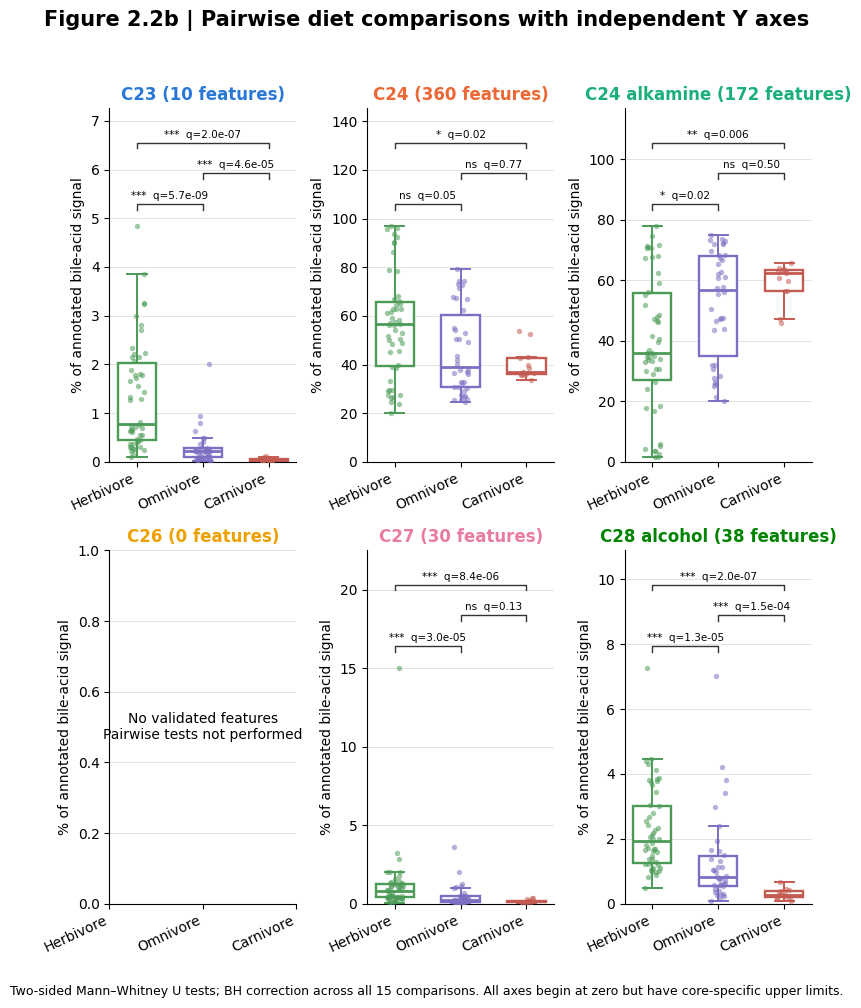

Figures and test tables written to /media/dorrestein/Helena2/Bile_acids_update/Manuscript/Github_refined/Figures/Figure2B_zoo_feces_use_case/figures/animal_zoo_diet


In [7]:
# Figure 2.2b: three pairwise diet comparisons per core, one Y scale per core.
fig22, axes = plt.subplots(2, 3, figsize=(8, 10), sharey=False)
rng = np.random.default_rng(54)
pair_levels = {(DIET_ORDER[0], DIET_ORDER[1]): 0,
               (DIET_ORDER[1], DIET_ORDER[2]): 1,
               (DIET_ORDER[0], DIET_ORDER[2]): 2}

for ax, core in zip(axes.flat, CORE_ORDER):
    if feature_counts[core] == 0:
        ax.text(.5, .5, 'No validated features\nPairwise tests not performed',
                ha='center', va='center', transform=ax.transAxes)
        ax.set_ylim(0, 1)
    else:
        values = [core_pct.loc[samples.index[samples['diet'].eq(d)], core].to_numpy()
                  for d in DIET_ORDER]
        styled_boxplot(ax, values, range(3), [DIET_COLORS[d] for d in DIET_ORDER])
        for j, (diet, vals) in enumerate(zip(DIET_ORDER, values)):
            ax.scatter(j + rng.uniform(-.12, .12, len(vals)), vals, s=15, alpha=.55,
                       color=DIET_COLORS[diet], linewidth=0, zorder=3)

        local_max = max(v.max() for v in values)
        local_span = max(local_max, 0.01)  # percentages are non-negative; baseline is zero
        bracket_base = local_max + .07 * local_span
        bracket_gap = .13 * local_span
        bracket_height = .025 * local_span
        subset = pairwise_diets.loc[pairwise_diets['core'].eq(core)]
        for row in subset.itertuples():
            level = pair_levels[(row.diet_1, row.diet_2)]
            x1, x2 = DIET_ORDER.index(row.diet_1), DIET_ORDER.index(row.diet_2)
            y = bracket_base + level * bracket_gap
            ax.plot([x1, x1, x2, x2],
                    [y, y + bracket_height, y + bracket_height, y],
                    color='#333333', linewidth=1, clip_on=False)
            ax.text((x1 + x2) / 2, y + bracket_height + .012 * local_span,
                    f'{row.significance}  q={format_q(row.q_value_BH)}',
                    ha='center', va='bottom', fontsize=7.5)
        ax.set_ylim(0, local_max + .50 * local_span)

    ax.set_xticks(range(3), [d.capitalize() for d in DIET_ORDER],
                  rotation=25, ha='right')
    ax.set_ylabel('% of annotated bile-acid signal')
    ax.set_title(f'{CORE_LABEL[core]} ({feature_counts[core]} features)',
                 color=CORE_COLORS[core], fontweight='bold')
    style_axis(ax)

fig22.suptitle('Figure 2.2b | Pairwise diet comparisons with independent Y axes',
               fontsize=15, fontweight='bold', y=.995)
fig22.text(.5, .01,
           'Two-sided Mann–Whitney U tests; BH correction across all 15 comparisons. '
           'All axes begin at zero but have core-specific upper limits.',
           ha='center', fontsize=9)
fig22.tight_layout(rect=(0, .035, 1, .97))
save_figure(fig22, 'figure2_2b_independent_y_axes')
plt.show()

if SAVE_FIGURES:
    pairwise_diets.to_csv(FIG_DIR / 'source_figure2_2b_pairwise_diet_tests.csv', index=False)
    print(f'Figures and test tables written to {FIG_DIR.resolve()}')

In [ ]:
# 